In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv("anantapur_balanced_crops.csv")

In [3]:
data


,pH,TDS,Turbidity,Temp,Season,KNN_Status,Recommended_Crop
0,7.20,1681,6,32,Summer,Normal,Pomegranate
1,7.40,787,27,45,Kharif,Abnormal,No Crops Suitable
2,9.60,1190,44,42,Rabi,Abnormal,No Crops Suitable
3,5.30,977,29,16,Rabi,Abnormal,No Crops Suitable
4,8.62,467,40,16,Rabi,Abnormal,No Crops Suitable
...,...,...,...,...,...,...,...
2995,8.75,529,6,40,Summer,Abnormal,No Crops Suitable
2996,6.16,2519,7,38,Summer,Abnormal,No Crops Suitable
2997,6.71,364,6,25,Kharif,Normal,Red Gram
2998,6.04,301,3,30,Kharif,Normal,Groundnut


In [4]:
data.columns

Index(['pH', 'TDS', 'Turbidity', 'Temp', 'Season', 'KNN_Status',
       'Recommended_Crop'],
      dtype='object')

In [5]:
print(data['Recommended_Crop'].value_counts())

Recommended_Crop
No Crops Suitable    1465
Pomegranate           113
Sunflower             108
Castor                106
Chillies              104
Mango                 101
Bengal Gram            99
Maize                  99
Cotton                 98
Sweet Orange           98
Jowar                  97
Banana                 96
Tomato                 93
Groundnut              90
Onion                  88
Red Gram               74
Paddy                  71
Name: count, dtype: int64


In [6]:
data=data[['pH', 'TDS', 'Turbidity', 'Temp',  'Recommended_Crop']]

In [7]:
data.isnull().sum()

pH                  0
TDS                 0
Turbidity           0
Temp                0
Recommended_Crop    0
dtype: int64

In [8]:
data.describe()

,pH,TDS,Turbidity,Temp
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,6.878713,1206.119667,14.927000,26.451000
std,1.338640,752.049133,14.749402,8.096879
min,4.010000,201.000000,0.000000,10.000000
25%,6.050000,607.000000,4.000000,21.000000
50%,6.760000,980.500000,9.000000,26.000000
75%,7.590000,1684.250000,25.000000,31.000000
max,9.990000,2999.000000,50.000000,45.000000


In [9]:
data.columns

Index(['pH', 'TDS', 'Turbidity', 'Temp', 'Recommended_Crop'], dtype='object')

Text(0.5, 0.98, 'Feature Distributions')

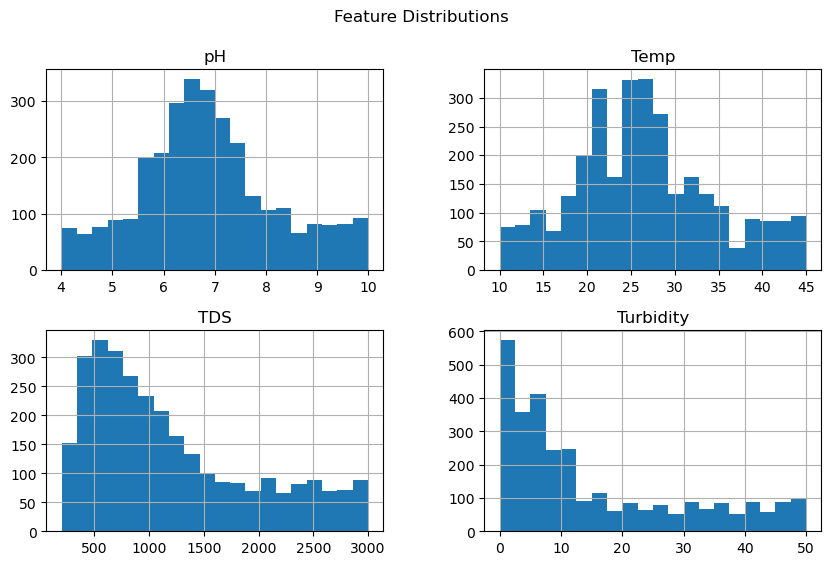

In [10]:
num_cols = ['pH', 'Temp', 'TDS', 'Turbidity']
data[num_cols].hist(bins=20, figsize=(10, 6))
plt.suptitle("Feature Distributions")

Text(0.5, 1.0, 'Boxplot for Outlier Detection')

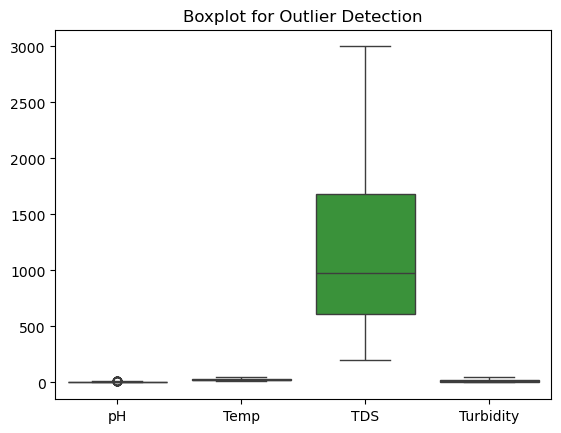

In [11]:
sns.boxplot(data=data[num_cols])
plt.title("Boxplot for Outlier Detection")

Text(0.5, 1.0, 'Correlation Heatmap')

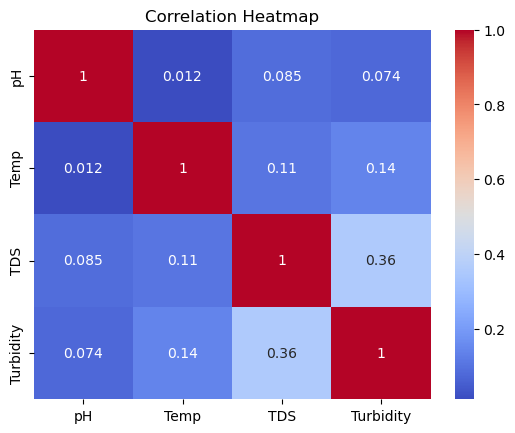

In [12]:
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

Text(0.5, 1.0, 'pH vs TDS')

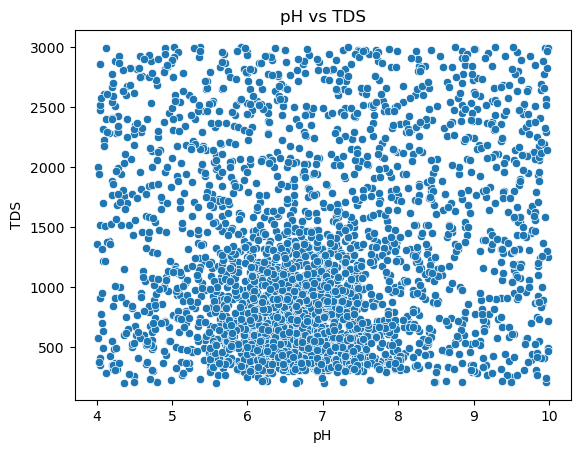

In [13]:
sns.scatterplot(x='pH', y='TDS', data=data)
plt.title("pH vs TDS")

Text(0.5, 1.0, 'Temperature vs Turbidity')

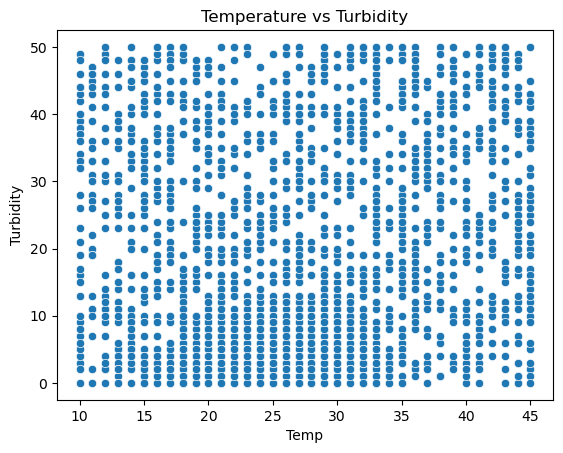

In [14]:
sns.scatterplot(x='Temp', y='Turbidity', data=data)
plt.title("Temperature vs Turbidity")

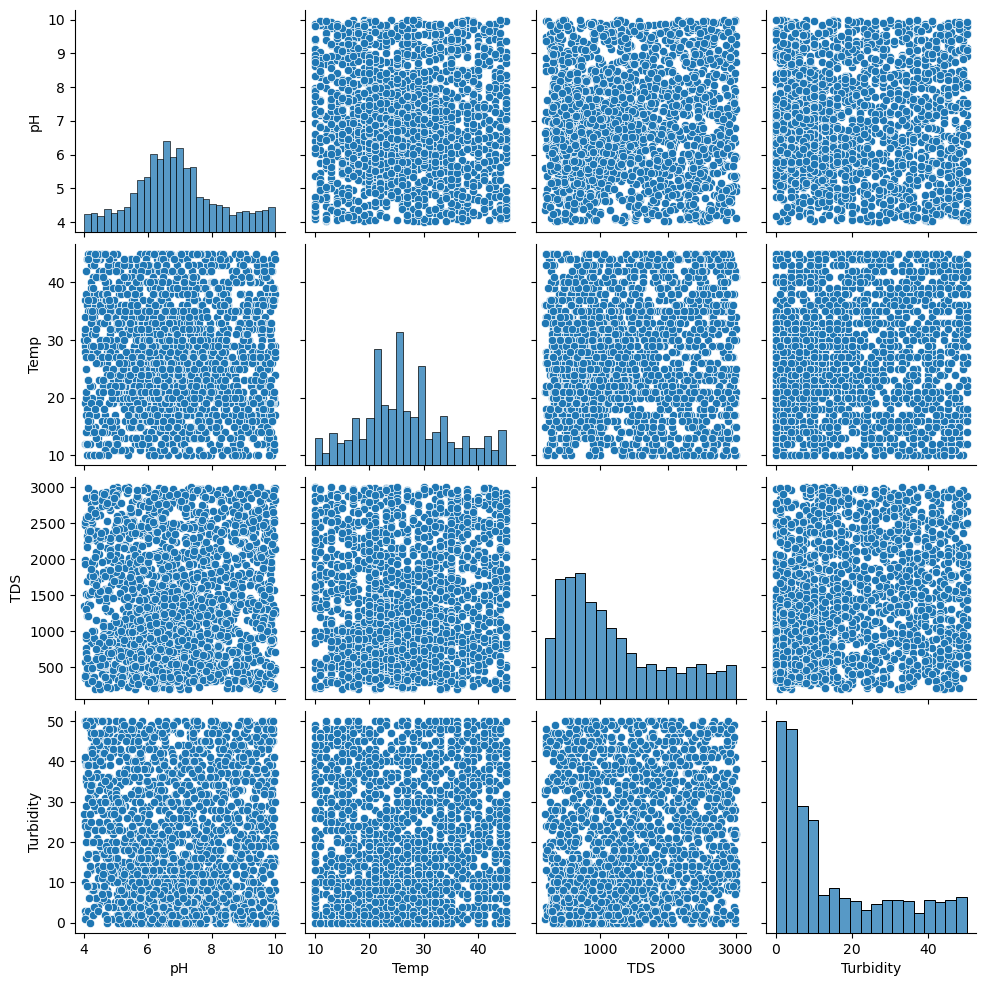

In [15]:
sns.pairplot(data[num_cols])

Text(0.5, 1.0, 'Crop Distribution')

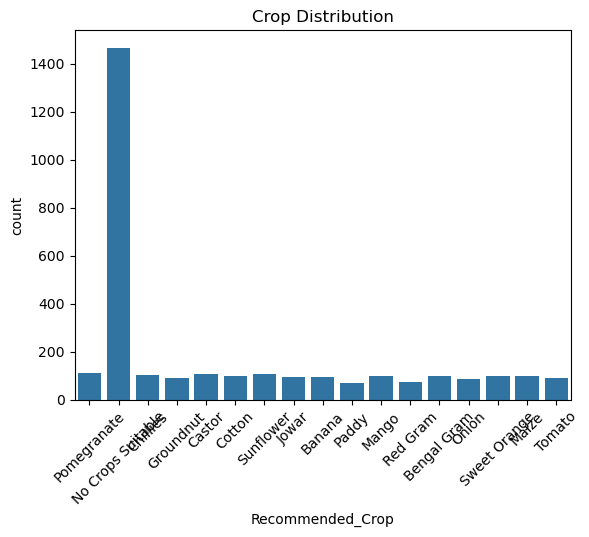

In [16]:
sns.countplot(x='Recommended_Crop', data=data)
plt.xticks(rotation=45)
plt.title("Crop Distribution")

Text(0.5, 1.0, 'Crop vs pH')

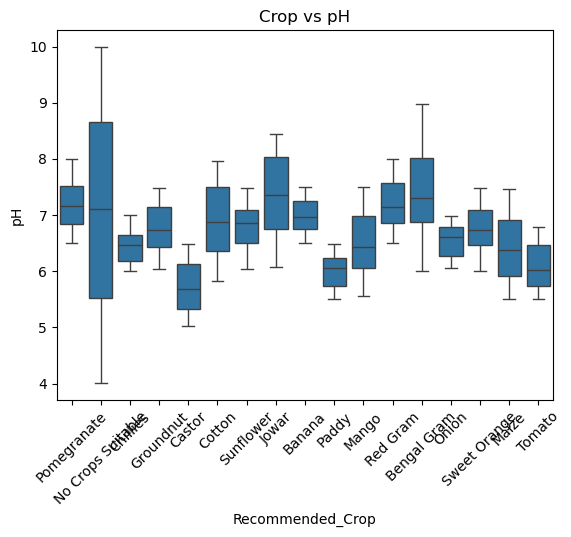

In [17]:
sns.boxplot(x='Recommended_Crop', y='pH', data=data)
plt.xticks(rotation=45)
plt.title("Crop vs pH")

Text(0.5, 1.0, 'Crop vs TDS')

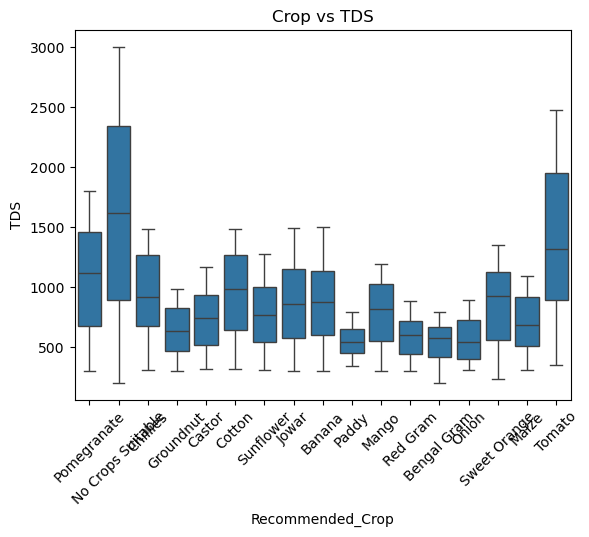

In [18]:
sns.boxplot(x='Recommended_Crop', y='TDS', data=data)
plt.xticks(rotation=45)
plt.title("Crop vs TDS")

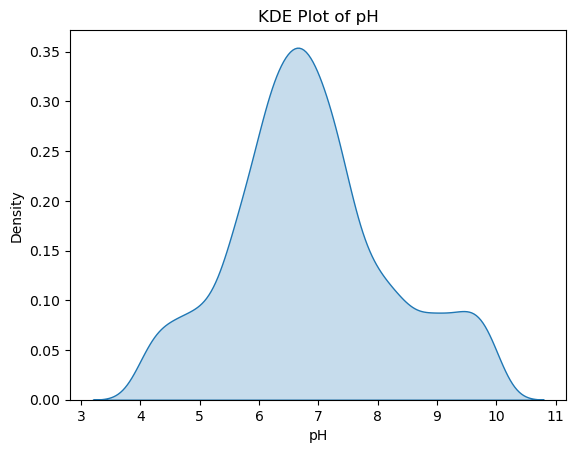

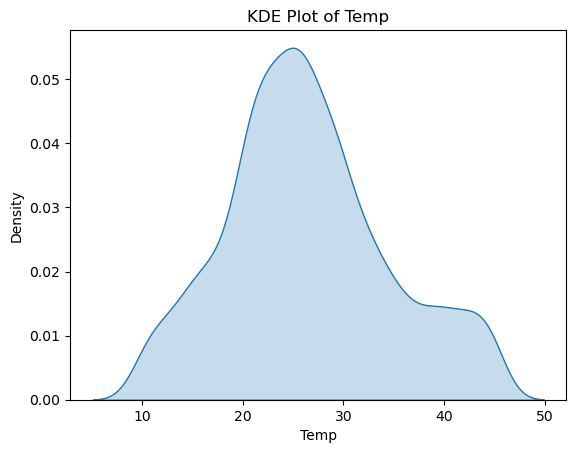

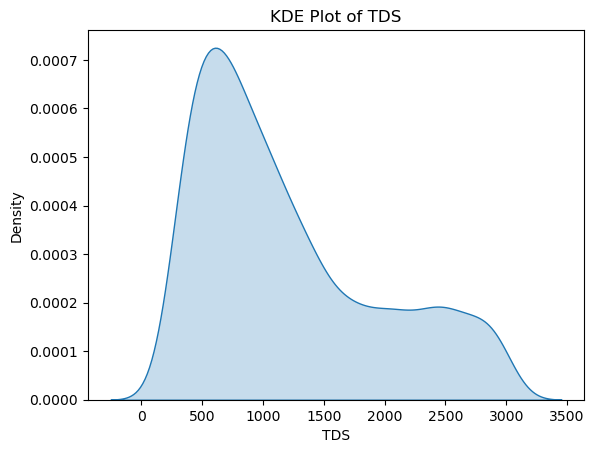

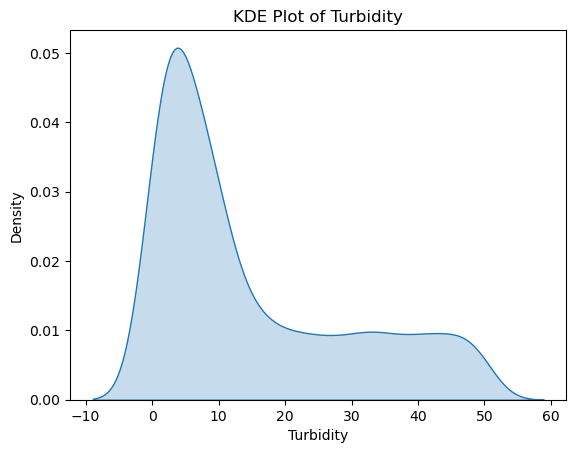

In [19]:
for col in num_cols:
    plt.figure()
    sns.kdeplot(data[col], fill=True)
    plt.title(f"KDE Plot of {col}")
    plt.show()

Text(0.5, 1.0, 'Crop vs pH (Violin Plot)')

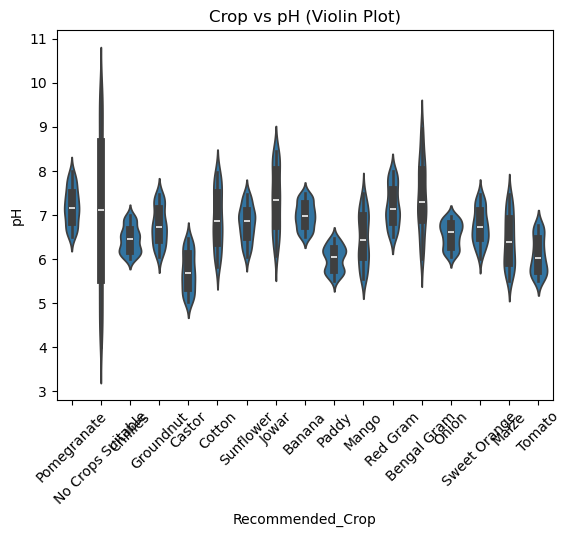

In [20]:
sns.violinplot(x='Recommended_Crop', y='pH', data=data)
plt.xticks(rotation=45)
plt.title("Crop vs pH (Violin Plot)")

Text(0.5, 1.0, 'Crop vs TDS (Violin Plot)')

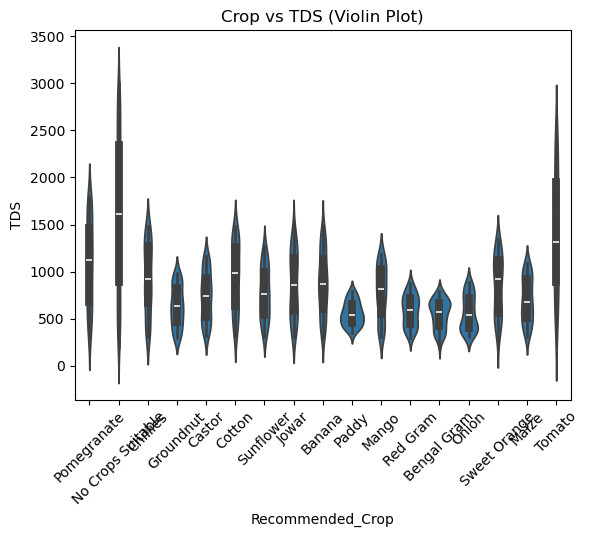

In [21]:
sns.violinplot(x='Recommended_Crop', y='TDS', data=data)
plt.xticks(rotation=45)
plt.title("Crop vs TDS (Violin Plot)")

Text(0.5, 1.0, 'Crop vs Temperature (Swarm Plot)')

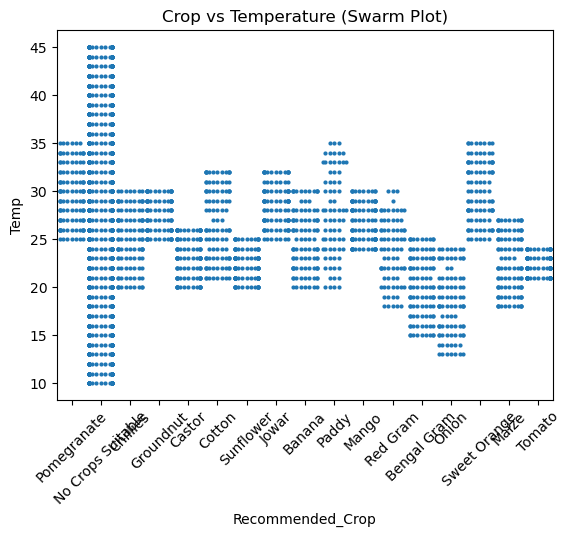

In [22]:
sns.swarmplot(x='Recommended_Crop', y='Temp', data=data, size=3)
plt.xticks(rotation=45)
plt.title("Crop vs Temperature (Swarm Plot)")

Text(0.5, 1.0, 'Temperature vs Turbidity (Colored by Crop)')

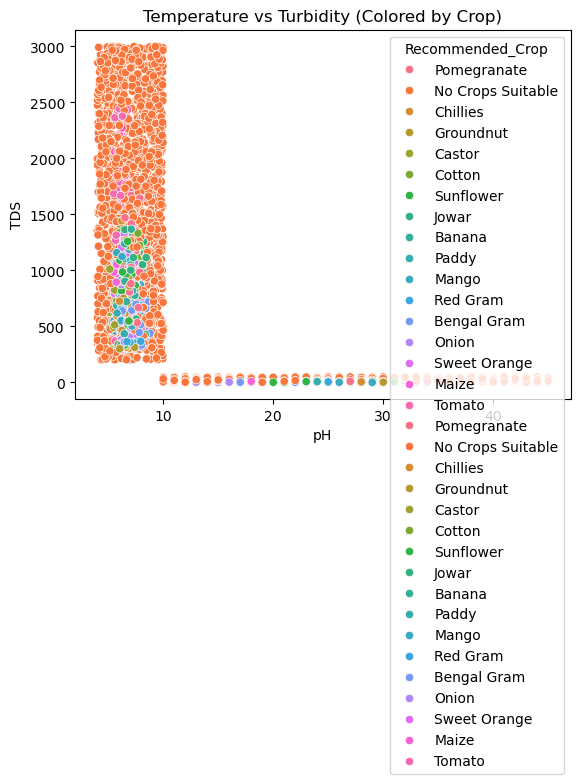

In [23]:
sns.scatterplot(x='pH', y='TDS', hue='Recommended_Crop', data=data)
plt.title("pH vs TDS (Colored by Crop)")


sns.scatterplot(x='Temp', y='Turbidity', hue='Recommended_Crop', data=data)
plt.title("Temperature vs Turbidity (Colored by Crop)")


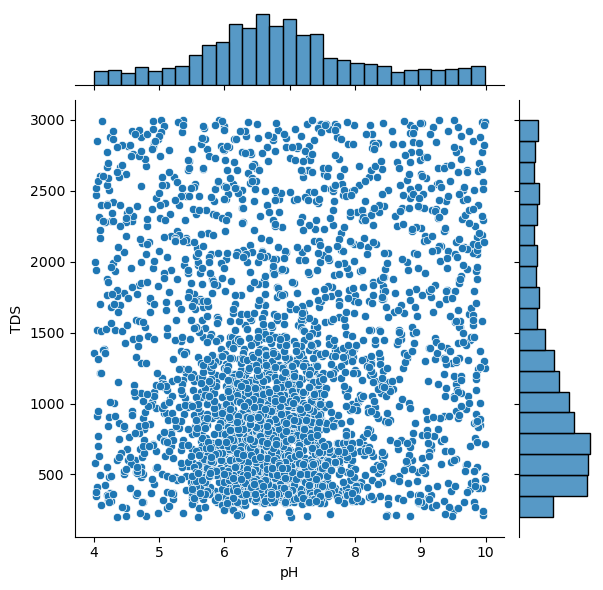

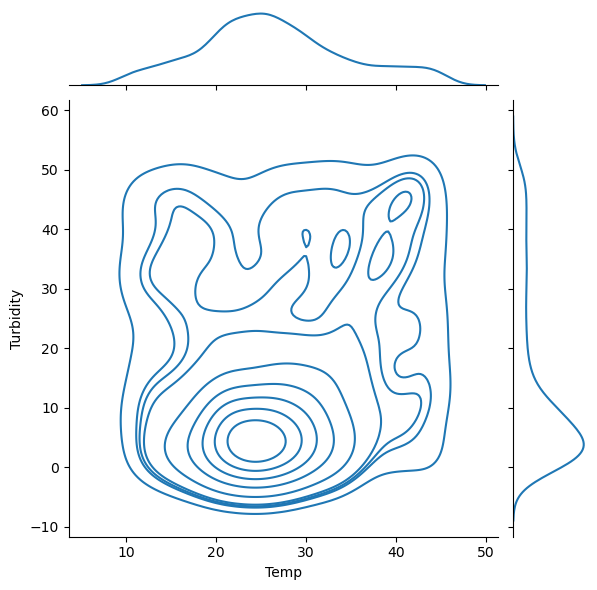

In [24]:
sns.jointplot(x='pH', y='TDS', data=data, kind='scatter')
sns.jointplot(x='Temp', y='Turbidity', data=data, kind='kde')

Text(0.5, 1.0, 'Crop vs Turbidity (Strip Plot)')

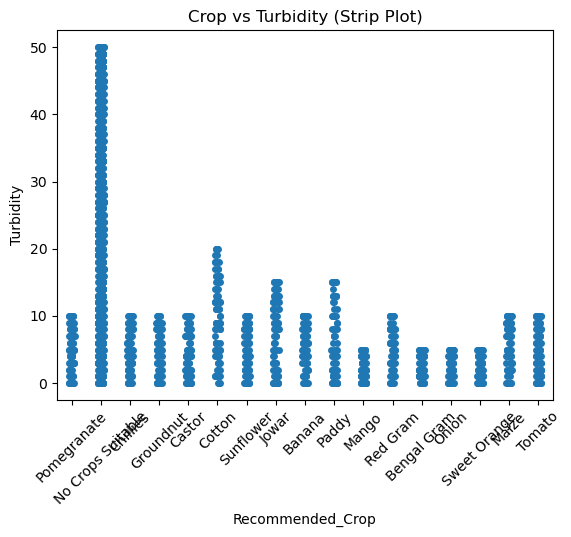

In [25]:
sns.stripplot(x='Recommended_Crop', y='Turbidity', data=data, jitter=True)
plt.xticks(rotation=45)
plt.title("Crop vs Turbidity (Strip Plot)")

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 [Text(0, 0, 'Banana'),
  Text(1, 0, 'Bengal Gram'),
  Text(2, 0, 'Castor'),
  Text(3, 0, 'Chillies'),
  Text(4, 0, 'Cotton'),
  Text(5, 0, 'Groundnut'),
  Text(6, 0, 'Jowar'),
  Text(7, 0, 'Maize'),
  Text(8, 0, 'Mango'),
  Text(9, 0, 'No Crops Suitable'),
  Text(10, 0, 'Onion'),
  Text(11, 0, 'Paddy'),
  Text(12, 0, 'Pomegranate'),
  Text(13, 0, 'Red Gram'),
  Text(14, 0, 'Sunflower'),
  Text(15, 0, 'Sweet Orange'),
  Text(16, 0, 'Tomato')])

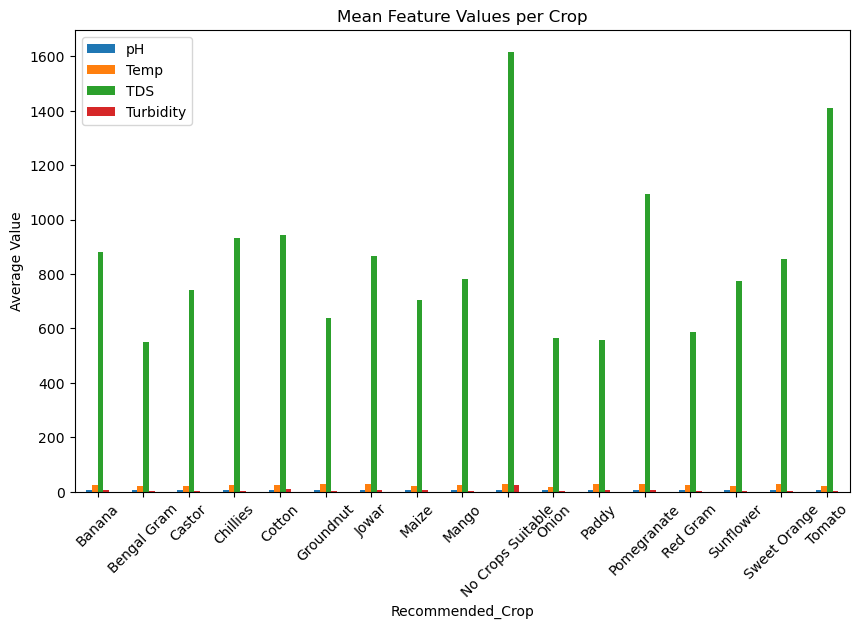

In [26]:
crop_means = data.groupby('Recommended_Crop')[num_cols].mean()
crop_means.plot(kind='bar', figsize=(10,6))
plt.title("Mean Feature Values per Crop")
plt.ylabel("Average Value")
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Radar Chart Example (Banana)')

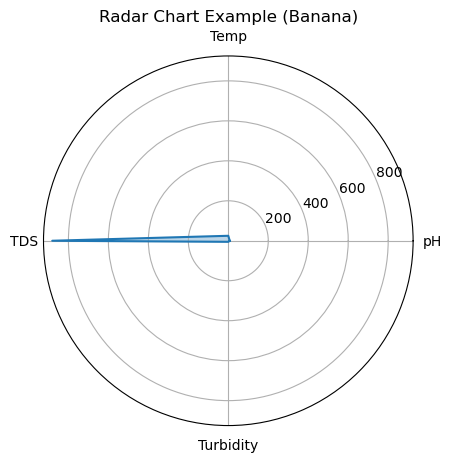

In [27]:
means = crop_means.iloc[0] 
labels = num_cols
values = means.values
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
values = np.concatenate((values, [values[0]]))
angles = np.concatenate((angles, [angles[0]]))
plt.polar(angles, values)
plt.fill(angles, values, alpha=0.3)
plt.xticks(angles[:-1], labels)
plt.title(f"Radar Chart Example ({crop_means.index[0]})")

Text(0.5, 1.0, 'Hexbin Plot: pH vs TDS')

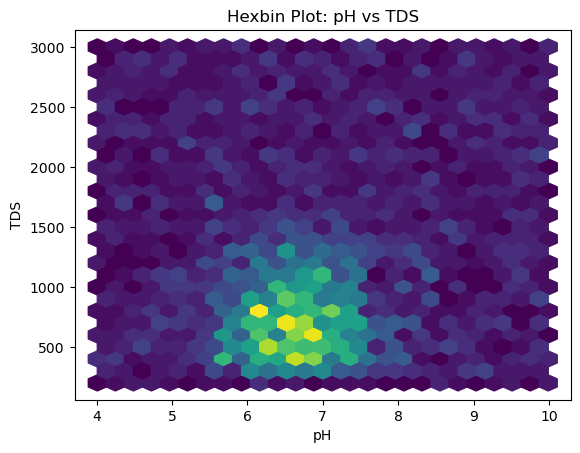

In [28]:
plt.hexbin(data['pH'], data['TDS'], gridsize=25)
plt.xlabel('pH')
plt.ylabel('TDS')
plt.title('Hexbin Plot: pH vs TDS')

Text(0.5, 1.0, 'Regression Plot: Temperature vs Turbidity')

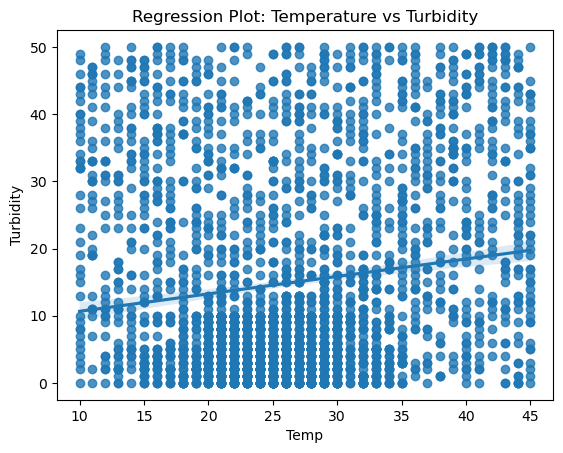

In [29]:
sns.regplot(x='Temp', y='Turbidity', data=data)
plt.title("Regression Plot: Temperature vs Turbidity")

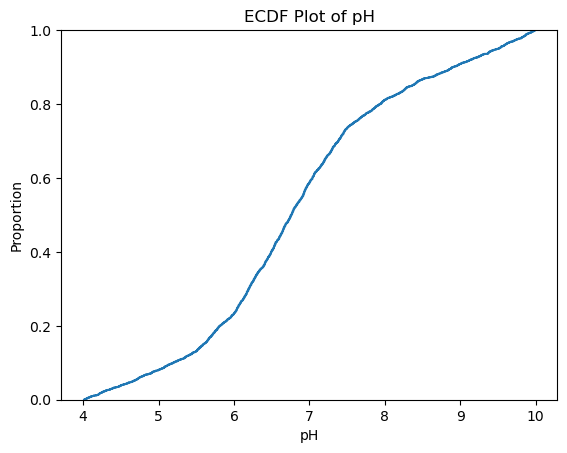

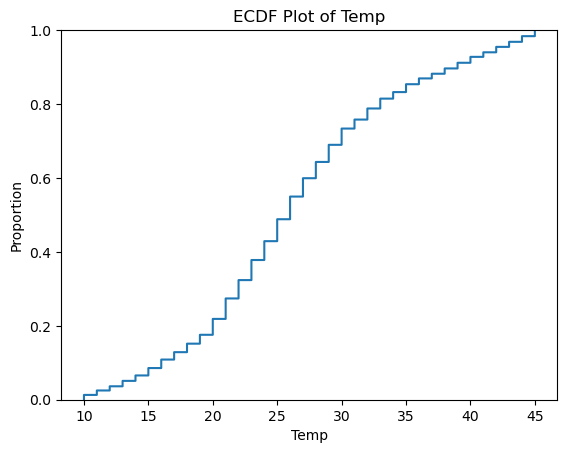

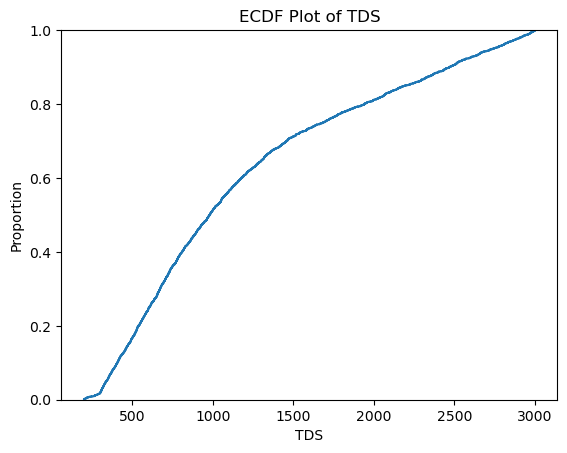

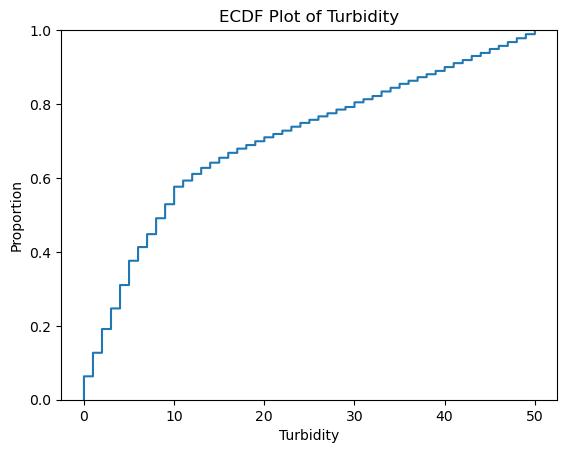

In [30]:
for col in num_cols:
    plt.figure()
    sns.ecdfplot(data[col])
    plt.title(f"ECDF Plot of {col}")

Text(0.5, 1.0, 'Boxen Plot: Crop vs TDS')

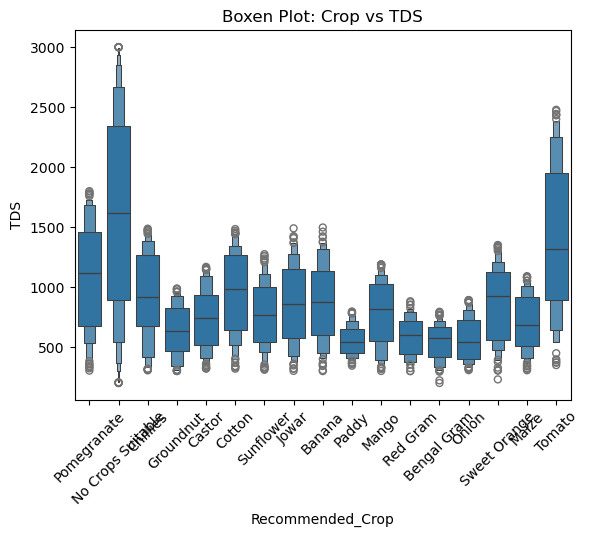

In [31]:
sns.boxenplot(x='Recommended_Crop', y='TDS', data=data)
plt.xticks(rotation=45)
plt.title("Boxen Plot: Crop vs TDS")

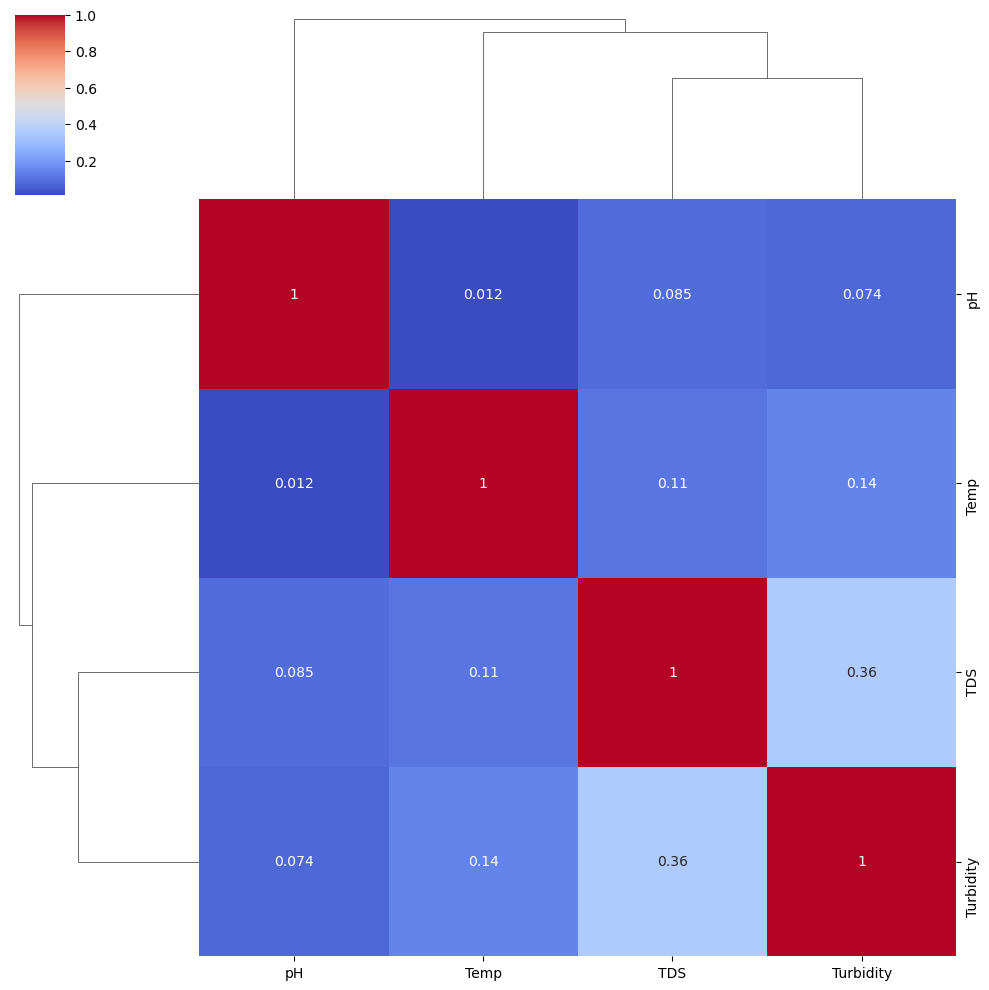

In [32]:
sns.clustermap(data[num_cols].corr(), annot=True, cmap='coolwarm')

(array([0, 1, 2, 3]),
 [Text(0, 0, 'pH'),
  Text(1, 0, 'Temp'),
  Text(2, 0, 'TDS'),
  Text(3, 0, 'Turbidity')])

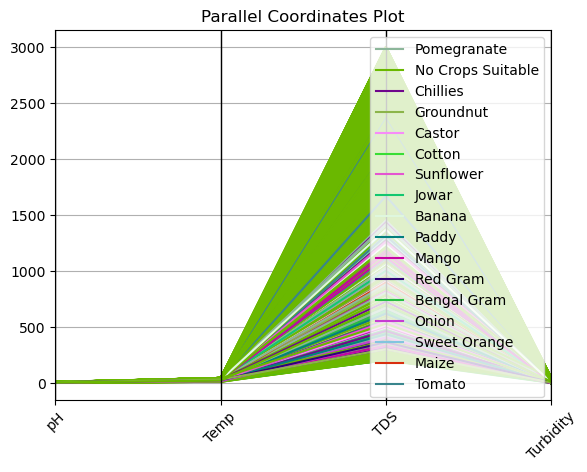

In [33]:
from pandas.plotting import parallel_coordinates
parallel_coordinates(data[['Recommended_Crop'] + num_cols], 'Recommended_Crop')
plt.title("Parallel Coordinates Plot")
plt.xticks(rotation=45)

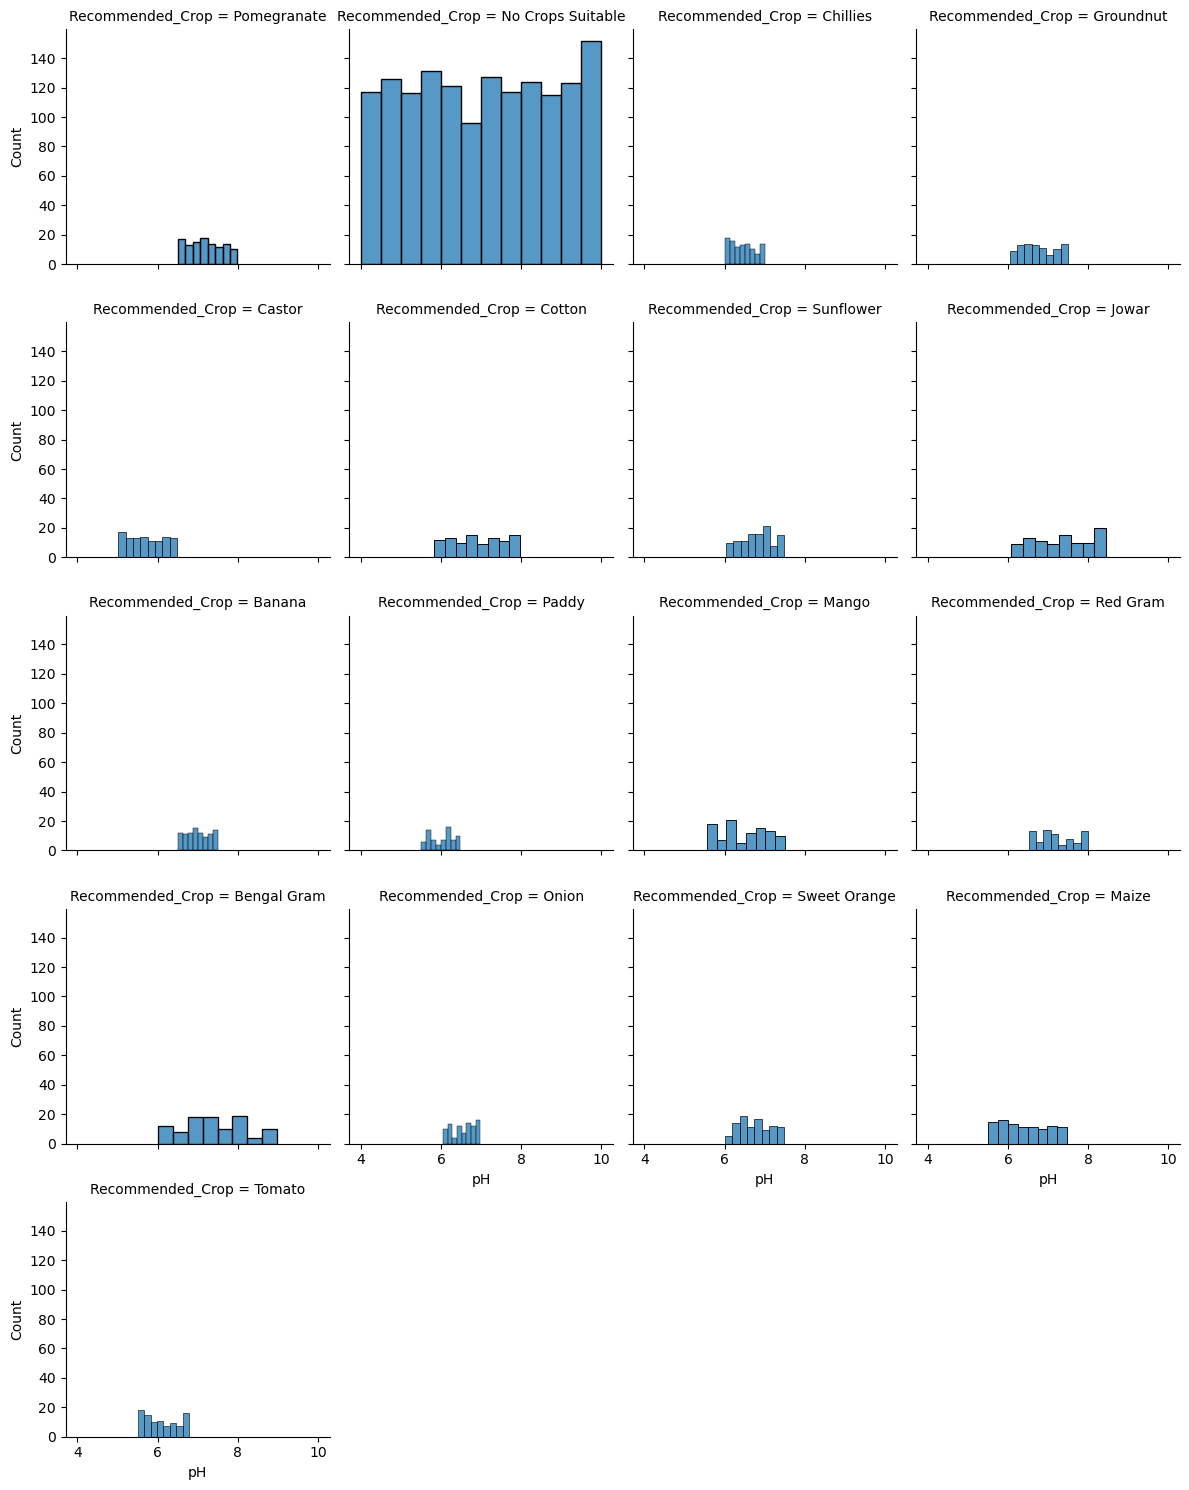

In [34]:
g = sns.FacetGrid(data, col="Recommended_Crop", col_wrap=4)
g.map(sns.histplot, "pH")

In [35]:
data

,pH,TDS,Turbidity,Temp,Recommended_Crop
0,7.20,1681,6,32,Pomegranate
1,7.40,787,27,45,No Crops Suitable
2,9.60,1190,44,42,No Crops Suitable
3,5.30,977,29,16,No Crops Suitable
4,8.62,467,40,16,No Crops Suitable
...,...,...,...,...,...
2995,8.75,529,6,40,No Crops Suitable
2996,6.16,2519,7,38,No Crops Suitable
2997,6.71,364,6,25,Red Gram
2998,6.04,301,3,30,Groundnut


In [36]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import joblib


# Encode Target
#target_encoder = LabelEncoder()
#data['Recommended_Crop'] = target_encoder.fit_transform(data['Recommended_Crop'])

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(data['Recommended_Crop'])

# Save encoder immediately
joblib.dump(target_encoder, "target_encoder.pkl")


X = data[['pH', 'TDS', 'Turbidity', 'Temp']]
y = data['Recommended_Crop']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After SMOTE distribution:")
print(pd.Series(y_train_res).value_counts())



After SMOTE distribution:
Recommended_Crop
Sunflower            1172
Paddy                1172
Onion                1172
Castor               1172
Banana               1172
Sweet Orange         1172
Tomato               1172
Cotton               1172
Bengal Gram          1172
No Crops Suitable    1172
Jowar                1172
Pomegranate          1172
Red Gram             1172
Maize                1172
Chillies             1172
Groundnut            1172
Mango                1172
Name: count, dtype: int64


In [39]:
le_season = LabelEncoder()
data['Recommended_Crop'] = le_season.fit_transform(data['Recommended_Crop'])
data['Recommended_Crop']

0       12
1        9
2        9
3        9
4        9
        ..
2995     9
2996     9
2997    13
2998     5
2999     9
Name: Recommended_Crop, Length: 3000, dtype: int32

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train_res, y_train_res, test_size=0.3, random_state=42
)


In [41]:
model_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

model_rf.fit(X_train, y_train)

# Evaluate
y_pred = model_rf.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))




Classification Report:

                   precision    recall  f1-score   support

           Banana       0.91      0.94      0.92       370
      Bengal Gram       0.95      0.96      0.95       358
           Castor       0.91      0.93      0.92       354
         Chillies       0.93      0.91      0.92       361
           Cotton       0.97      0.88      0.92       347
        Groundnut       0.92      0.95      0.94       373
            Jowar       0.94      0.97      0.96       360
            Maize       0.91      0.90      0.91       332
            Mango       0.94      0.91      0.93       364
No Crops Suitable       1.00      0.95      0.98       322
            Onion       0.93      0.97      0.95       337
            Paddy       0.97      0.98      0.97       362
      Pomegranate       0.95      0.92      0.94       391
         Red Gram       0.96      0.93      0.95       332
        Sunflower       0.92      0.94      0.93       356
     Sweet Orange       0.89  

In [42]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}


In [43]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\nModel:", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Model: Logistic Regression
Accuracy: 0.3880896620943459
                   precision    recall  f1-score   support

           Banana       0.28      0.14      0.19       370
      Bengal Gram       0.54      0.65      0.59       358
           Castor       0.51      0.64      0.57       354
         Chillies       0.16      0.10      0.12       361
           Cotton       0.22      0.25      0.23       347
        Groundnut       0.33      0.26      0.29       373
            Jowar       0.44      0.35      0.39       360
            Maize       0.10      0.08      0.09       332
            Mango       0.26      0.24      0.25       364
No Crops Suitable       0.70      0.68      0.69       322
            Onion       0.62      0.71      0.66       337
            Paddy       0.39      0.45      0.42       362
      Pomegranate       0.40      0.39      0.40       391
         Red Gram       0.28      0.37      0.32       332
        Sunflower       0.28      0.24      0.26       35

In [44]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} Average CV Accuracy: {scores.mean():.4f}")


Logistic Regression Average CV Accuracy: 0.4830
KNN Average CV Accuracy: 0.4900
SVM Average CV Accuracy: 0.4883
Decision Tree Average CV Accuracy: 0.6513
Random Forest Average CV Accuracy: 0.6837


In [45]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} Average CV Accuracy: {scores.mean():.4f}")


Logistic Regression Average CV Accuracy: 0.4830
KNN Average CV Accuracy: 0.4900
SVM Average CV Accuracy: 0.4883
Decision Tree Average CV Accuracy: 0.6537
Random Forest Average CV Accuracy: 0.6857


In [46]:
rf = RandomForestClassifier()
rf.fit(X, y)

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': ['pH', 'TDS', 'Turbidity', 'Temp'],
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)


     Feature  Importance
2  Turbidity    0.281464
0         pH    0.268377
1        TDS    0.260307
3       Temp    0.189852


In [47]:
accuracies = {}
best_model = None
best_score = 0
best_model_name = ""
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    if acc > best_score:
        best_score = acc
        best_model = model
        best_model_name = name

print("Best Model:", best_model_name)
print("Best Accuracy:", best_score)

Best Model: Random Forest
Best Accuracy: 0.935095349615256


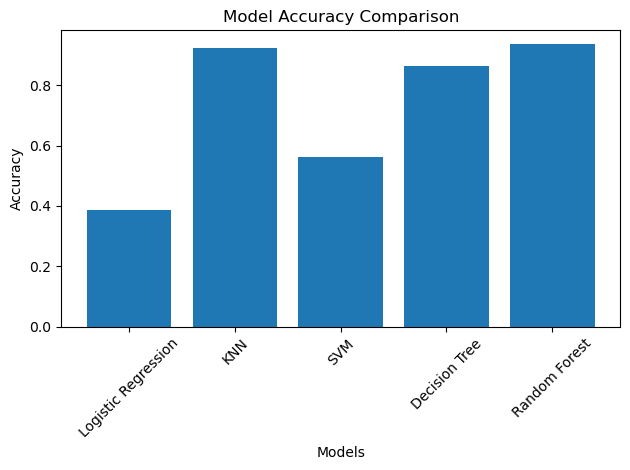

In [48]:
plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [49]:
import joblib
joblib.dump(model_rf, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

#joblib.dump(le_season, "target_encoder.pkl")
print("Model and preprocessors saved successfully!")

Model and preprocessors saved successfully!


In [50]:
import joblib
import pandas as pd

# Load saved model and preprocessors
model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")


print("Model and preprocessors loaded successfully!")


Model and preprocessors loaded successfully!


In [51]:
model.predict([[6.71	,364,	6,	25]])

array(['No Crops Suitable'], dtype=object)

In [52]:
model.predict([[7.20,	1681,	6,	32]])


array(['No Crops Suitable'], dtype=object)

In [54]:
import joblib

# Load encoder
target_encoder = joblib.load("target_encoder.pkl")

prediction = model.predict([[6.71, 364, 6, 25]])  # include Season if used
print(prediction)



['No Crops Suitable']


In [ ]:
print(target_encoder.classes_)

In [55]:
import joblib

# Load encoder
target_encoder = joblib.load("target_encoder.pkl")

prediction = model.predict([[6.04,	301	,3,	30]])  # include Season if used
print(prediction)


['No Crops Suitable']
